
## Taller: NLP básico → Vectores → Word2Vec → BERT → Transformers

**Dataset:** Rotten Tomatoes (sentiment)

### Objetivo general

Entender el pipeline de NLP moderno, desde limpieza y vectorización hasta BERT y una primera mirada a Transformers.

### Qué vas a hacer (5 puntos)
1) Limpieza + tokenización + stopwords (NLP básico)
2) Texto → vectores (TF-IDF) + modelo ML baseline
3) Word2Vec (repaso): embeddings "estáticos"
4) BERT: embeddings contextuales + evaluación rápida en sentimiento
5) Transformers: ideas clave + tareas NLP (sentiment/translation/summarization) con pipelines

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Variables de entorno (deben ir primero, antes de importar HuggingFace)
# ──────────────────────────────────────────────────────────────────────────────
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# ──────────────────────────────────────────────────────────────────────────────
# Advertencias
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ──────────────────────────────────────────────────────────────────────────────
# Manipulación y análisis de datos
# ──────────────────────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
from collections import Counter

# ──────────────────────────────────────────────────────────────────────────────
# Visualización
# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# NLP — NLTK
# ──────────────────────────────────────────────────────────────────────────────
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# ──────────────────────────────────────────────────────────────────────────────
# NLP — Gensim
# ──────────────────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec

# ──────────────────────────────────────────────────────────────────────────────
# Machine Learning — Scikit-learn
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────────────────────────────────────
# Deep Learning — PyTorch
# ──────────────────────────────────────────────────────────────────────────────
import torch

# ──────────────────────────────────────────────────────────────────────────────
# NLP — HuggingFace (Transformers + Datasets)
# ──────────────────────────────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    MarianMTModel,
    MarianTokenizer,
    pipeline,
)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

device = 0 if torch.cuda.is_available() else -1

### ═══════════════════════════════════════════════════════════════════════════════
### 1) CARGAR DATASET ROTTEN TOMATOES + EDA RÁPIDO
### Objetivo: cargar el dataset, convertirlo a DataFrame y explorar su estructura.
### ═══════════════════════════════════════════════════════════════════════════════

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1) CARGAR DATASET ROTTEN TOMATOES + EDA RÁPIDO
# Objetivo: cargar el dataset, convertirlo a DataFrame y explorar su estructura.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Cargar dataset desde HuggingFace
# Splits disponibles: train / validation / test
# ──────────────────────────────────────────────────────────────────────────────
ds = load_dataset("rotten_tomatoes")

# ──────────────────────────────────────────────────────────────────────────────
# Convertir cada split a DataFrame para trabajar con pandas
# label: 0 = negativo | 1 = positivo
# ──────────────────────────────────────────────────────────────────────────────
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

# ──────────────────────────────────────────────────────────────────────────────
# EDA rápido: tamaño, balance de clases y primeras filas
# ──────────────────────────────────────────────────────────────────────────────
print(15*"═")
print("Tamaño de cada split")
print(15*"═")
print(f"  Train : {len(train_df):,} filas")
print(f"  Val   : {len(val_df):,} filas")
print(f"  Test  : {len(test_df):,} filas")

print(15*"═")
print("Balance de clases (train)")
print(15*"═")
print(train_df["label"].value_counts().rename({0: "negativo", 1: "positivo"}))

print(15*"═")
print("Primeras filas")
print(15*"═")
train_df.head()

'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /datasets/rotten_tomatoes/resolve/main/README.md (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: CA cert does not include key usage extension (_ssl.c:1032)')))"), '(Request ID: 8f7a3601-6eae-4e0a-a01c-18325310b5b1)')' thrown while requesting HEAD https://huggingface.co/datasets/rotten_tomatoes/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /datasets/rotten_tomatoes/resolve/main/README.md (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: CA cert does not include key usage extension (_ssl.c:1032)')))"), '(Request ID: 43b79369-b60a-47a6-8b0c-3c7fc6866711)')' thrown while requesting HEAD https://huggingface.co/datasets/rotten_tomatoes/resolve/main/README.md
Retrying i

ConnectionError: Couldn't reach 'rotten_tomatoes' on the Hub (SSLError)

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.1) DISTRIBUCIÓN DE CLASES
# Objetivo: verificar si el dataset está balanceado antes de modelar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Conteo numérico: cuántas reseñas positivas vs negativas hay en train
# ──────────────────────────────────────────────────────────────────────────────
print("=== Conteo de clases ===")
print(train_df["label"].value_counts().rename({0: "negativo", 1: "positivo"}))

# ──────────────────────────────────────────────────────────────────────────────
# Visualización: si las barras son iguales → dataset balanceado → no hay sesgo
# ──────────────────────────────────────────────────────────────────────────────
plt.figure()
train_df["label"].value_counts().plot(kind="bar")
plt.title("Balance de clases (train) — Rotten Tomatoes")
plt.xlabel("label  (0 = negativo | 1 = positivo)")
plt.ylabel("conteo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

label
1    4265
0    4265
Name: count, dtype: int64

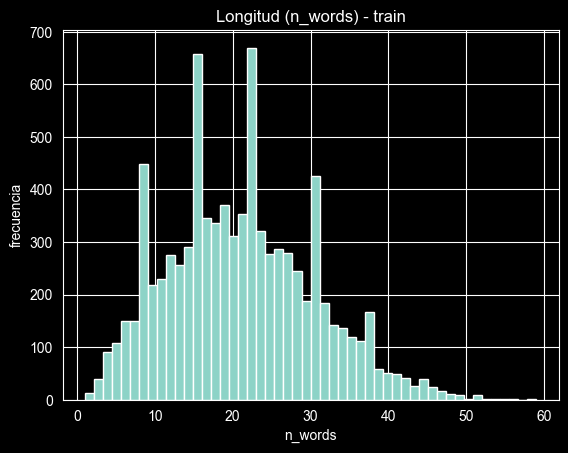

count    8530.000000
mean       20.992849
std         9.371094
min         1.000000
25%        14.000000
50%        20.000000
75%        27.000000
max        59.000000
Name: n_words, dtype: float64

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.2) LONGITUD DE LAS RESEÑAS
# Objetivo: entender cuántas palabras tienen las reseñas (antes de limpiar).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Crear columna con el número de palabras por reseña (split por espacios)
# ──────────────────────────────────────────────────────────────────────────────
train_df["n_words"] = train_df["text"].str.split().apply(len)

# ──────────────────────────────────────────────────────────────────────────────
# Histograma: muestra si las reseñas son cortas/largas y si hay outliers
# ──────────────────────────────────────────────────────────────────────────────
plt.figure()
plt.hist(train_df["n_words"], bins=50)
plt.title("Distribución de longitud — train")
plt.xlabel("n_words")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Estadísticas: media, mediana, máximo → útil para decidir truncado en BERT
# ──────────────────────────────────────────────────────────────────────────────
print(train_df["n_words"].describe().round(1))

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.3) PIPELINE DE LIMPIEZA DE TEXTO
# Objetivo: dejar el texto en forma estándar antes de vectorizar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Stopwords en inglés, pero conservando negaciones (no, not, n't)
# porque "not good" ≠ "good" → eliminarlas destruiría el sentido
# ──────────────────────────────────────────────────────────────────────────────
EN_STOPWORDS      = set(stopwords.words("english"))
NEGATIONS         = {"no", "not", "nor", "n't"}
EN_STOPWORDS_SAFE = EN_STOPWORDS - NEGATIONS

# ──────────────────────────────────────────────────────────────────────────────
# clean_text_basic → quita HTML, pasa a minúsculas, elimina caracteres raros
# tokenize         → limpia y parte el texto en lista de palabras
# remove_stopwords → filtra palabras vacías (artículos, preposiciones, etc.)
# preprocess       → aplica todo el pipeline y devuelve texto limpio como string
# ──────────────────────────────────────────────────────────────────────────────
def clean_text_basic(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", text)   # saltos de línea HTML
    text = re.sub(r"<.*?>",     " ", text)   # cualquier otra etiqueta HTML
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)  # conserva apóstrofe (don't)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str) -> list:
    return clean_text_basic(text).split()

def remove_stopwords(tokens: list, stopset=EN_STOPWORDS_SAFE) -> list:
    return [t for t in tokens if t not in stopset]

def preprocess(text: str) -> str:
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sebas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.4) APLICAR PREPROCESAMIENTO A LOS TRES SPLITS
# Objetivo: generar la columna text_clean lista para vectorizar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Aplicar preprocess() fila a fila en cada split
# Se crea una nueva columna para conservar el texto original intacto
# ──────────────────────────────────────────────────────────────────────────────
train_df["text_clean"] = train_df["text"].apply(preprocess)
val_df["text_clean"]   = val_df["text"].apply(preprocess)
test_df["text_clean"]  = test_df["text"].apply(preprocess)

# ──────────────────────────────────────────────────────────────────────────────
# Verificación visual: comparar texto original vs texto limpio
# ──────────────────────────────────────────────────────────────────────────────
train_df[["text", "text_clean"]].head(3)

,text,text_clean
0,the rock is destined to be the 21st century's ...,rock destined 21st century's new conan going m...
1,"the gorgeously elaborate continuation of "" the...",gorgeously elaborate continuation lord rings t...
2,effective but too-tepid biopic,effective tepid biopic


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.5) PALABRAS MÁS FRECUENTES POST-LIMPIEZA
# Objetivo: verificar que el preprocesamiento funciona y que quedan
#           palabras con contenido semántico real (no ruido).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Contar palabras en las primeras 3000 reseñas limpias
# Si aparecen artículos o preposiciones → la limpieza falló
# Si aparecen palabras como "film", "story", "bad" → está bien
# ──────────────────────────────────────────────────────────────────────────────
counter = Counter()
for texto in train_df["text_clean"].head(3000):
    counter.update(texto.split())

print("=== Top 20 palabras más frecuentes ===")
for palabra, freq in counter.most_common(20):
    print(f"  {palabra:<15} {freq:,}")

[('film', 437),
 ('movie', 288),
 ('not', 209),
 ('one', 192),
 ('like', 154),
 ('story', 124),
 ('good', 120),
 ('comedy', 120),
 ('well', 118),
 ('even', 115),
 ('way', 112),
 ('time', 107),
 ('best', 99),
 ('much', 88),
 ('make', 87),
 ('director', 87),
 ('funny', 87),
 ('life', 87),
 ('love', 85),
 ('characters', 85)]

### ═══════════════════════════════════════════════════════════════════════════════
### 2) TEXTO → VECTORES (TF-IDF) + MODELO BASELINE (LinearSVC)
### Objetivo: convertir texto limpio en números y entrenar un clasificador
###           clásico para tener un punto de referencia antes de usar BERT.
### ═══════════════════════════════════════════════════════════════════════════════

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2) TEXTO → VECTORES (TF-IDF) + MODELO BASELINE (LinearSVC)
# Objetivo: convertir texto limpio en números y entrenar un clasificador
#           clásico para tener un punto de referencia antes de usar BERT.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Separar texto y etiquetas para train y validación
# ──────────────────────────────────────────────────────────────────────────────
X_train, y_train = train_df["text_clean"].values, train_df["label"].values
X_val,   y_val   = val_df["text_clean"].values,   val_df["label"].values

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       533
           1       0.76      0.75      0.76       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066



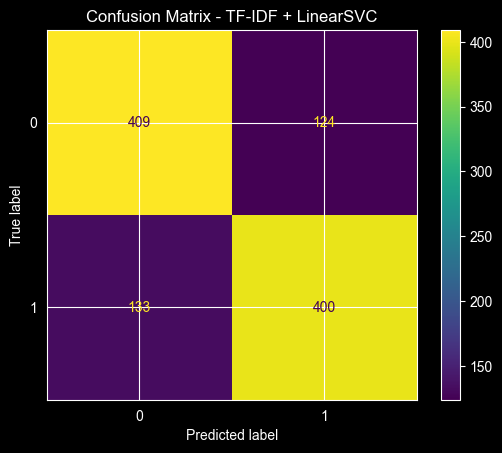

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.1) VECTORIZACIÓN TF-IDF
# Objetivo: convertir cada reseña en un vector de números que representa
#           qué tan importantes son sus palabras dentro del corpus.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF penaliza palabras muy comunes y premia las distintivas
#   max_features=20000  → vocabulario máximo de 20k términos
#   ngram_range=(1,2)   → incluye unigramas ("good") y bigramas ("not good")
#   min_df=2            → ignora términos que aparecen en menos de 2 reseñas
#   sublinear_tf=True   → aplica log(tf) para reducir el peso de palabras
#                         muy repetidas dentro de una misma reseña
# ──────────────────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

# fit_transform en train: aprende el vocabulario Y transforma
# transform en val:       solo transforma (sin re-aprender) → evita data leakage
Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)

print(f"Matriz train : {Xtr.shape}  (reseñas × términos)")
print(f"Matriz val   : {Xva.shape}")

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.2) MODELO BASELINE — LinearSVC
# Objetivo: encontrar el hiperplano que mejor separa reseñas positivas
#           de negativas en el espacio TF-IDF.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# LinearSVC es muy eficiente en espacios de alta dimensión (20k features)
# Es el baseline clásico para clasificación de texto
# ──────────────────────────────────────────────────────────────────────────────
svm = LinearSVC()
svm.fit(Xtr, y_train)

pred_val = svm.predict(Xva)

# ──────────────────────────────────────────────────────────────────────────────
# classification_report muestra precision, recall y F1 por clase
# Nos interesa que ambas clases (0 y 1) tengan F1 alto y similar
# ──────────────────────────────────────────────────────────────────────────────
print("=== Reporte de clasificación — TF-IDF + LinearSVC ===\n")
print(classification_report(y_val, pred_val, target_names=["negativo", "positivo"]))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.3) MATRIZ DE CONFUSIÓN
# Objetivo: ver exactamente dónde se equivoca el modelo
#           (falsos positivos vs falsos negativos).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Diagonal principal → predicciones correctas
# Fuera de diagonal  → errores del modelo
#   [0,1] = negativos clasificados como positivos (falsos positivos)
#   [1,0] = positivos clasificados como negativos (falsos negativos)
# ──────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, pred_val)
ConfusionMatrixDisplay(cm, display_labels=["negativo", "positivo"]).plot()
plt.title("Matriz de Confusión — TF-IDF + LinearSVC")
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.4) PREGUNTA GUÍA
# ¿Por qué un modelo lineal funciona tan bien con TF-IDF?
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF convierte texto en vectores de 20k dimensiones → espacio muy disperso
# En espacios de alta dimensión los datos suelen ser linealmente separables:
# hay suficiente "lugar" para trazar un hiperplano entre clases
#
# Además, el sentimiento en reseñas de cine depende fuertemente de palabras
# clave ("brilliant", "terrible", "not good") que TF-IDF captura bien con
# bigramas → el modelo lineal solo necesita aprender el peso de cada término
#
# Conclusión: TF-IDF + LinearSVC es difícil de superar en datasets pequeños
# y bien limpios. BERT ganará cuando el contexto importa más que las palabras.
# ──────────────────────────────────────────────────────────────────────────────

### ═══════════════════════════════════════════════════════════════════════════════
### 3) WORD2VEC — EMBEDDINGS ESTÁTICOS
### Objetivo: representar palabras como vectores densos aprendidos del corpus,
###           y comparar su rendimiento contra TF-IDF del punto anterior.
### ═══════════════════════════════════════════════════════════════════════════════

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3) WORD2VEC — EMBEDDINGS ESTÁTICOS
# Objetivo: representar palabras como vectores densos aprendidos del corpus,
#           y comparar su rendimiento contra TF-IDF del punto anterior.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Word2Vec necesita listas de tokens (no strings)
# Usamos text_clean que ya está limpio y sin stopwords
# ──────────────────────────────────────────────────────────────────────────────
sentences = [t.split() for t in train_df["text_clean"].values]

[('not', 0.9998488426208496),
 ('would', 0.9998477101325989),
 ('one', 0.9998475313186646),
 ('much', 0.9998442530632019),
 ('plot', 0.9998422861099243),
 ('film', 0.9998397827148438),
 ('enough', 0.9998380541801453),
 ('us', 0.9998363852500916),
 ('movie', 0.9998311996459961),
 ('films', 0.9998270869255066)]

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.1) ENTRENAR WORD2VEC
# Objetivo: aprender un vector de 100 números por cada palabra del corpus,
#           donde palabras con contextos similares quedan cerca en el espacio.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# vector_size=100  → cada palabra = vector de 100 dimensiones
# window=5         → aprende del contexto de 5 palabras a cada lado
# min_count=3      → ignora palabras que aparecen menos de 3 veces
# workers=2        → hilos de entrenamiento en paralelo
# ──────────────────────────────────────────────────────────────────────────────
w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2,
)

# ──────────────────────────────────────────────────────────────────────────────
# Prueba de sanidad: palabras similares a "good" en el espacio aprendido
# Si el modelo aprendió bien → aparecerán sinónimos o palabras de sentimiento
# ──────────────────────────────────────────────────────────────────────────────
print("=== Palabras más similares a 'good' ===")
for palabra, score in w2v.wv.most_similar("good", topn=10):
    print(f"  {palabra:<20} similitud: {score:.3f}")

((8530, 100), (1066, 100))

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.2) EMBEDDING DE FRASE POR PROMEDIO DE VECTORES
# Objetivo: convertir una reseña completa en un solo vector de 100 números
#           promediando los vectores de cada palabra que la compone.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Estrategia: promediar todos los vectores de la frase
# Limitación: el orden y contexto se pierden → "not good" y "good" quedan cerca
# Palabras fuera del vocabulario se ignoran; si no hay ninguna → vector cero
# ──────────────────────────────────────────────────────────────────────────────
def sentence_embedding_avg(text: str, model: Word2Vec, dim: int = 100) -> np.ndarray:
    vecs = [model.wv[tok] for tok in text.split() if tok in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

Xtr_emb = np.vstack([sentence_embedding_avg(t, w2v) for t in X_train])
Xva_emb = np.vstack([sentence_embedding_avg(t, w2v) for t in X_val])

print(f"Matriz train : {Xtr_emb.shape}  (reseñas × dimensiones)")
print(f"Matriz val   : {Xva_emb.shape}")

Word2Vec(avg) + LogisticRegression
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       533
           1       0.51      0.48      0.49       533

    accuracy                           0.51      1066
   macro avg       0.51      0.51      0.51      1066
weighted avg       0.51      0.51      0.51      1066



In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.3) CLASIFICADOR SOBRE EMBEDDINGS PROMEDIO
# Objetivo: medir qué tan útil es la representación Word2Vec para sentimiento.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# LogisticRegression sobre vectores densos de 100 dims
# max_iter=2000 porque con embeddings densos converge más lento que con TF-IDF
# ──────────────────────────────────────────────────────────────────────────────
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_emb, y_train)

pred_emb = clf.predict(Xva_emb)

print("=== Word2Vec (avg) + LogisticRegression ===\n")
print(classification_report(y_val, pred_emb, target_names=["negativo", "positivo"]))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.4) DISCUSIÓN — ¿POR QUÉ TF-IDF SUELE GANARLE A WORD2VEC AQUÍ?
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF gana en textos cortos porque cada palabra clave pesa directamente
# Word2Vec-promedio pierde esa señal al promediar: una sola palabra negativa
# ("terrible") queda diluida entre todas las positivas de la frase
#
# Además Word2Vec es ESTÁTICO → el vector de "bank" es siempre el mismo,
# sin importar si habla de un banco financiero o de la orilla de un río
#
# Esta limitación es exactamente la motivación para BERT:
#   → embeddings CONTEXTUALES donde cada palabra tiene un vector distinto
#     dependiendo de las palabras que la rodean en esa oración específica
# ──────────────────────────────────────────────────────────────────────────────

### ═══════════════════════════════════════════════════════════════════════════════
### 4) BERT — EMBEDDINGS CONTEXTUALES + EVALUACIÓN EN SENTIMIENTO
### Objetivo: usar un modelo Transformer preentrenado (DistilBERT) para clasificar
###           sentimiento sin entrenar desde cero — solo inferencia directa.
### ═══════════════════════════════════════════════════════════════════════════════

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4) BERT — EMBEDDINGS CONTEXTUALES + EVALUACIÓN EN SENTIMIENTO
# Objetivo: usar un modelo Transformer preentrenado (DistilBERT) para clasificar
#           sentimiento sin entrenar desde cero — solo inferencia directa.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Detectar si hay GPU disponible
# device=0 → usa GPU  |  device=-1 → usa CPU
# ──────────────────────────────────────────────────────────────────────────────
device = 0 if torch.cuda.is_available() else -1
print(f"Dispositivo: {'GPU' if device == 0 else 'CPU'}")

[{'label': 'NEGATIVE', 'score': 0.9997581839561462}]

In [1]:
# %%


# Dataset
ds = load_dataset("rotten_tomatoes")
val_df = ds["validation"].to_pandas()

# Modelo
device = 0 if torch.cuda.is_available() else -1
bert_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

# Evaluación
N = 400
texts_eval = val_df["text"].tolist()[:N]
y_true = val_df["label"].values[:N]

pred_labels = []
for t in texts_eval:
    out = bert_sentiment(t)[0]
    pred_labels.append(1 if out["label"] == "POSITIVE" else 0)

acc = accuracy_score(y_true, pred_labels)
print("Accuracy (DistilBERT SST-2) en subset val:", acc)

Accuracy (DistilBERT SST-2) en subset val: 0.9125


In [ ]:
# **Preguntas para responder**
# 1) ¿Cómo se compara este accuracy vs TF-IDF + SVM?
# 2) ¿Qué ventaja tiene un Transformer preentrenado?
# 3) ¿Por qué no fue necesario entrenarlo desde cero aquí?

###Punto 5 — Transformers: ideas clave + tareas NLP (más allá de sentimiento)

In [ ]:
## **Ideas clave**
# - Un Transformer usa "attention": cada palabra mira a las demás para entender contexto.
# - Por eso captura relaciones de largo alcance mejor que enfoques clásicos.
# - BERT (encoder) es muy bueno entendiendo; GPT (decoder) es muy bueno generando.

In [3]:
# %%


device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Helsinki-NLP/opus-mt-en-es"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)

def translate(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        output = model.generate(**inputs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

translate("This movie is not good. The story is confusing and the acting is weak.")

'Esta película no es buena, la historia es confusa y la actuación es débil.'

In [4]:
# %%


device = 0 if torch.cuda.is_available() else -1

summarizer = pipeline(
    "summarization",
    model="sshleifer/distilbart-cnn-12-6",
    device=device
)

long_text = """
The film begins with an interesting idea, but the execution is uneven.
Some scenes feel engaging, yet the pacing slows down in the middle.
The performances vary from strong to flat, and the dialogue can be repetitive.
In the end, the movie has a few memorable moments, but it does not fully deliver on its promise.
"""

summarizer(long_text, max_length=60, min_length=20, do_sample=False)

[{'summary_text': ' Some scenes feel engaging, yet the pacing slows down in the middle . The performances vary from strong to flat, and the dialogue can be repetitive .'}]

In [5]:
# ## Entregables
# 1) Resultados de TF-IDF + SVM (métricas)
# 2) Word2Vec: ejemplo de similitud + clasificación con embedding promedio
# 3) BERT: accuracy en un subset + comparación con TF-IDF
# 4) Responder 5 preguntas conceptuales:
#    - Diferencia TF-IDF vs Word2Vec vs BERT
#    - Qué significa "contextual"
#    - Por qué negaciones importan en stopwords
#    - Qué tareas adicionales soporta un Transformer
#    - Cuándo usarías un baseline clásico vs un Transformer